![image.png](https://i.imgur.com/a3uAqnb.png)

# Variational Autoencoder (VAE) for Anime Portrait Generation
- **Images**: Anime-style portrait images **(64x64, RGB)**
- **Classes**: Various anime characters, but for VAE we **ignore labels**
- **Shape**: `(batch_size, 3, 64, 64)` → 3 RGB channels



## 1️⃣ Dataset Class

In [ ]:
!pip install datasets==2.20.0
!pip install huggingface_hub==0.24.6
!pip install fsspec==2024.6.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.8/547.8 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.1/316.1 kB 30.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.5.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.5/417.5 kB 32.3 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled

In [ ]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from datasets import load_dataset
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
from tqdm import tqdm
import torch.nn.functional as F
import torch.optim as optim

In [ ]:
# Custom Dataset class for Hugging Face dataset
class AnimeDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image = self.dataset[idx]['image']
        if isinstance(image, np.ndarray):
            image = Image.fromarray(image)
        elif not isinstance(image, Image.Image):
            image = Image.open(image).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, 0  # Return dummy label for compatibility

In [ ]:
# Define transformations
transform = transforms.Compose([
    transforms.Resize((64, 64)),  # Resize to 64x64
    transforms.ToTensor(),        # Convert to tensor [0,1]
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # Normalize to [-1,1]
])

In [ ]:
hf_dataset = load_dataset("quindici1515/Anime_style_portrait_dataset", split="train")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/4000 [00:00<?, ? examples/s]

In [ ]:
train_dataset = AnimeDataset(hf_dataset, transform=transform)

In [ ]:
batch_size =  256 # Reduced batch size for larger images
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

# Check dataset size
print(f"Training samples: {len(train_dataset)}")

Training samples: 4000


### Let's display some images

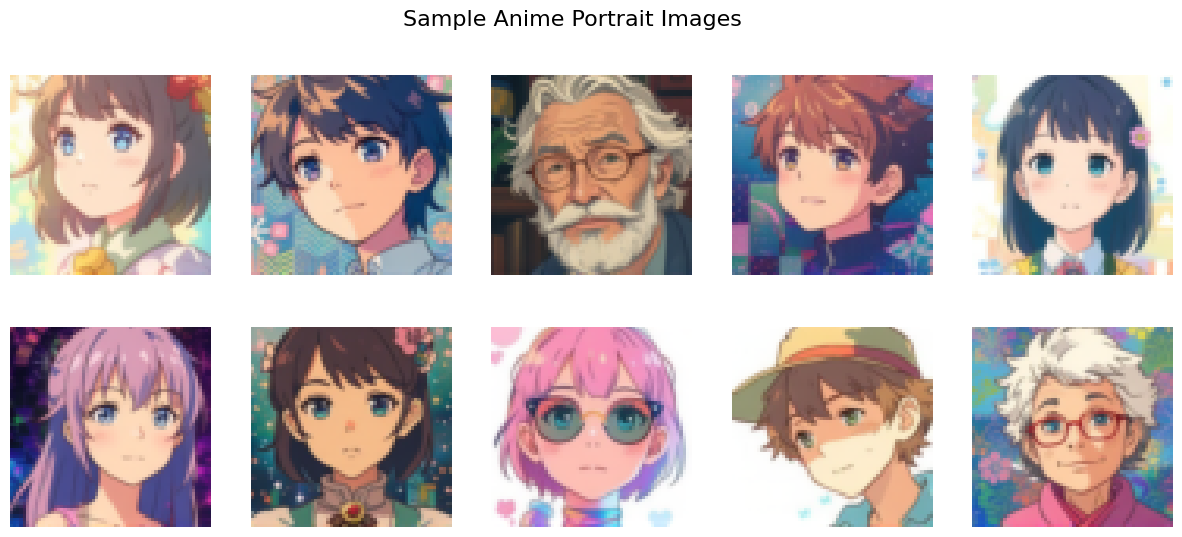

Shape of one image tensor: torch.Size([3, 64, 64])


In [ ]:
# Get a batch of training data
data_iter = iter(train_loader)
images, _ = next(data_iter)  # Labels are ignored in VAE

# Denormalize images for display
def denormalize(tensor):
    return (tensor * 0.5) + 0.5  # Convert from [-1,1] to [0,1]

# Show images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0)  # Change from (C,H,W) to (H,W,C)
    img = torch.clamp(img, 0, 1)  # Ensure values are in [0,1]

    ax.imshow(img.numpy())
    ax.axis("off")

plt.suptitle("Sample Anime Portrait Images", fontsize=16)
plt.show()

# Show shape of one image
print("Shape of one image tensor:", images[0].shape)  # Expected: (3, 64, 64)

## 2️⃣ Model Class

# **📌 Variational Autoencoder (VAE) Model**
A **Variational Autoencoder (VAE)** is a generative model that learns to **encode data into a probabilistic latent space** and **decode it back to reconstruct the original data**.

## **🔹 Key Differences from Standard Autoencoder**
1️⃣ **Probabilistic Encoding**
   - Instead of deterministic encoding, VAE learns **mean (μ) and log-variance (σ²)** of latent distribution
   - Uses **reparameterization trick** to sample from learned distribution

2️⃣ **KL Divergence Loss**
   - Regularizes latent space to follow standard normal distribution
   - Enables smooth interpolation and generation

3️⃣ **Better Generation**
   - Can generate new samples by sampling from prior distribution
   - More structured and meaningful latent space

![VAE Architecture](https://miro.medium.com/v2/resize:fit:4800/format:webp/1*r1R0cxCnErWgE0P4Q-hI0Q.jpeg)

## **📌 Expected Input & Output Shapes**
- **Input:** `(batch_size, 3, 64, 64)`
- **Encoded μ, σ:** `(batch_size, latent_dim)`
- **Decoded Output:** `(batch_size, 3, 64, 64)`

## 📌 VAE Loss Functions

### Equations:
* $
\text{Reconstruction Loss} = \sum (x - \hat{x})^2  MSE
$

* $
\text{KL Loss} = -\frac{1}{2} \sum \left(1 + \log \sigma^2 - \mu^2 - \sigma^2 \right)
$


* $\text{Total Loss} = \text{Reconstruction Loss} + \cdot \text{KL Loss}$

* $\text{Total Loss} = \text{Reconstruction Loss} + \beta \cdot \text{KL Loss}$ (with $\beta$  - VAE extention)



## 3️⃣ Training and Validation Loops

We will train the VAE model to learn meaningful representations of anime portraits.

1️⃣ **Forward Pass** → Encode to μ, σ, sample z, and decode

2️⃣ **Compute Loss** → Reconstruction loss + KL divergence

3️⃣ **Backward Pass** → Update model parameters

## 4️⃣ Running Training

VAE uses a combination of reconstruction loss and KL divergence loss to learn meaningful latent representations.


## Plot losses
#### Total Loss
#### Reconstruction Los
#### KL Divergence

# Plot some predictions

# Generate some images

The quality of generated images heavily depends on the model architecture, latent dimension size, dataset complexity, and training duration. These might not look perfect after a short training run.

### Contributed by: Ali Habibullah.
(Updated from Mohamed Eltayeb's original MNIST Autoencoder)